<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/Kaggle_Study_Practice/04_CIFAR_10_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d pankrzysiu/cifar10-python
!unzip cifar10-python.zip -d ./cifar10

Dataset URL: https://www.kaggle.com/datasets/pankrzysiu/cifar10-python
License(s): other
100% 325M/325M [00:10<00:00, 33.6MB/s]

Archive:  cifar10-python.zip
  inflating: ./cifar10/cifar-10-batches-py/batches.meta  
  inflating: ./cifar10/cifar-10-batches-py/data_batch_1  
  inflating: ./cifar10/cifar-10-batches-py/data_batch_2  
  inflating: ./cifar10/cifar-10-batches-py/data_batch_3  
  inflating: ./cifar10/cifar-10-batches-py/data_batch_4  
  inflating: ./cifar10/cifar-10-batches-py/data_batch_5  
  inflating: ./cifar10/cifar-10-batches-py/readme.html  
  inflating: ./cifar10/cifar-10-batches-py/test_batch  
  inflating: ./cifar10/cifar-10-python.tar.gz  


In [2]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class KaggleCIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        if isinstance(label, np.ndarray):
            label = int(label[0]) if label.size == 1 else int(np.argmax(label))
        else:
            label = int(label)

        return image, label

In [3]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d

In [4]:
all_images, all_labels = [], []

for i in range(1, 6):
    batch_path = f"./cifar10/cifar-10-batches-py/data_batch_{i}"
    batch_dict = unpickle(batch_path)

    all_images.append(batch_dict[b'data'])
    all_labels.extend(batch_dict[b'labels'])

x_train_raw = np.vstack(all_images)
y_train = np.array(all_labels)
print(x_train_raw.shape)

x_train = x_train_raw.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(x_train.shape, y_train.shape)

(50000, 3072)
(50000, 32, 32, 3) (50000,)


In [5]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = KaggleCIFAR10Dataset(images=x_train, labels=y_train, transform=train_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_dataset), len(train_loader))

50000 782


torch.Size([64, 3, 32, 32])


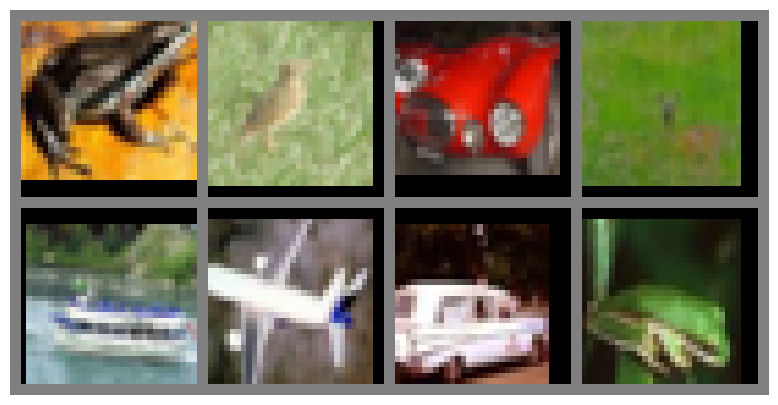

['frog', 'bird', 'automobile', 'deer', 'ship', 'airplane', 'automobile', 'frog']


In [6]:
import matplotlib.pyplot as plt
import torchvision

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    img = img / 2 + 0.5

    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images.shape)

img_grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.figure(figsize=(10, 5))
imshow(img_grid)
plt.show()
print([classes[labels[j]] for j in range(8)])

In [7]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 3

model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {i+1} | Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

Epoch 1 | Batch 100 | Loss: 1.8933
Epoch 1 | Batch 200 | Loss: 1.6194
Epoch 1 | Batch 300 | Loss: 1.5282
Epoch 1 | Batch 400 | Loss: 1.4260
Epoch 1 | Batch 500 | Loss: 1.3212
Epoch 1 | Batch 600 | Loss: 1.2782
Epoch 1 | Batch 700 | Loss: 1.2179
Epoch 2 | Batch 100 | Loss: 1.1270
Epoch 2 | Batch 200 | Loss: 1.0740
Epoch 2 | Batch 300 | Loss: 1.0623
Epoch 2 | Batch 400 | Loss: 1.0042
Epoch 2 | Batch 500 | Loss: 0.9873
Epoch 2 | Batch 600 | Loss: 0.9621
Epoch 2 | Batch 700 | Loss: 0.9639
Epoch 3 | Batch 100 | Loss: 0.9108
Epoch 3 | Batch 200 | Loss: 0.8954
Epoch 3 | Batch 300 | Loss: 0.8653
Epoch 3 | Batch 400 | Loss: 0.8390
Epoch 3 | Batch 500 | Loss: 0.8386
Epoch 3 | Batch 600 | Loss: 0.8382
Epoch 3 | Batch 700 | Loss: 0.7800


In [9]:
test_batch_path = './cifar10/cifar-10-batches-py/test_batch'
test_dict = unpickle(test_batch_path)

x_test_raw = test_dict[b'data']
y_test = np.array(test_dict[b'labels'])

x_test = x_test_raw.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(x_test.shape)
print(len(x_test))
# print(type(y_test))
# print(len(y_test))
print(y_test.shape)

(10000, 32, 32, 3)
10000
(10000,)


In [10]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_dataset = KaggleCIFAR10Dataset(images=x_test, labels=y_test, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(len(test_dataset), len(test_loader))

10000 157


In [11]:
model.eval()

correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"{correct} / 10000")
print(f"Accuracy: {accuracy:.2f}")

7449 / 10000
Accuracy: 74.49
